In [4]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_1 = pd.read_csv('Central_tendency_metric.csv',sep='\t', encoding='ISO-8859-1')
#分别计算分数的算数平均值、截尾均值、加权平均值、中位数、众数、中列数
num_cols = df_1.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 0:
    col = num_cols[1]
else:
    raise ValueError('没有找到数值列用于计算')
# 算术平均值
mean = df_1[col].mean()
# 截尾均值
def trimmed_mean(series, proportiontocut=0.1):
    series_clean = series.dropna().sort_values()
    n = len(series_clean)
    cut = int(np.floor(proportiontocut * n))
    if n - 2*cut <= 0:
        return series_clean.mean()
    return series_clean.iloc[cut: n-cut].mean()
trim_mean = trimmed_mean(df_1[col], 0.1)
# 加权平均（如果有权重列 'weight' 或 '权重'），否则与算术平均相同
if len(num_cols) > 2:
    weights = df_1[num_cols[2]]
else:
    weights = None
if weights is not None:
    weighted_mean = (df_1[col] * weights).sum() / weights.sum()
else:
    weighted_mean = mean
# 中位数
median = df_1[col].median()
# 计算众数，可能有多个
modes = df_1[col].mode().tolist()
# 中列数
mid_range = (df_1[col].min() + df_1[col].max()) / 2

print(f'算术平均值: {mean}')
print(f'截尾均值: {trim_mean}')
print(f'加权平均值: {weighted_mean}')
print(f'中位数: {median}')
print(f'众数: {modes}')
print(f'中列数: {mid_range}')


算术平均值: 72.0
截尾均值: 73.375
加权平均值: 72.0
中位数: 73.5
众数: [100]
中列数: 66.5


In [ ]:
df_2 = pd.read_csv('Data_Decentralization_Metrics.csv', sep='\t', encoding='ISO-8859-1')
#分别计算上述数据的极差、最小值（基于n-1）、最大值（基于n-1)
#计算下四分位数Q1（基于n-1)、中位数（基于n-1)、上四分位数Q3（基于n-1)、下四分位数Q1（基于n+1)、中位数（基于n+1)、上四分位数Q3（基于n+1)
#计算样本方差、总体方差、样本标准差、总体标准差等

num_cols = df_2.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise ValueError('没有找到数值列用于去中心化指标计算。')
col = num_cols[1]
s = df_2[col].dropna()
n = len(s)
# 极差
range_ = s.max() - s.min()
# 最小/最大值
min_val = s.min()
max_val = s.max()
# 计算基于 n-1 或 n+1 的四分位数
def calculate_quartiles(data, method='n-1'):
    data_sorted = np.sort(data)
    n = len(data_sorted)
    
    if method == 'n-1':
        Q1_pos = 0.25 * (n - 1) + 1
        Q2_pos = 0.50 * (n - 1) + 1
        Q3_pos = 0.75 * (n - 1) + 1
    elif method == 'n+1':
        Q1_pos = 0.25 * (n + 1)
        Q2_pos = 0.50 * (n + 1)
        Q3_pos = 0.75 * (n + 1)
    else:
        raise ValueError("Method must be 'n-1' or 'n+1'")
    
    def interpolate_position(pos):
        if pos.is_integer():
            return data_sorted[int(pos) - 1]
        else:
            lower = int(pos) - 1
            upper = lower + 1
            return data_sorted[lower] + (pos - (lower + 1)) * (data_sorted[upper] - data_sorted[lower])
    
    Q1 = interpolate_position(Q1_pos)
    Q2 = interpolate_position(Q2_pos)
    Q3 = interpolate_position(Q3_pos)
    
    return Q1, Q2, Q3

Q1_n_1, Q2_n_1, Q3_n_1 = calculate_quartiles(s, method='n-1')

Q1_n_1, Q2_n_1, Q3_n_1 = calculate_quartiles(s, method='n+1')

# 方差与标准差：样本（ddof=1） 与 总体（ddof=0）
var_sample = s.var(ddof=1)
var_population = s.var(ddof=0)
std_sample = s.std(ddof=1)
std_population = s.std(ddof=0)

print(f'极差: {range_}')
print(f'最小值: {min_val}, 最大值: {max_val}')
print("基于 n-1 的四分位数:")
print(f"Q1: {Q1_n_1}, Q2: {Q2_n_1}, Q3: {Q3_n_1}")
print("基于 n+1 的四分位数:")
print(f"Q1: {Q1_n_1}, Q2: {Q2_n_1}, Q3: {Q3_n_1}")
print(f'样本方差 (ddof=1): {var_sample}')
print(f'总体方差 (ddof=0): {var_population}')
print(f'样本标准差 (ddof=1): {std_sample}')
print(f'总体标准差 (ddof=0): {std_population}')


基于 n-1 的四分位数:
Q1: 61.25, Q2: 73.5, Q3: 87.5
基于 n+1 的四分位数:
Q1: 56.25, Q2: 73.5, Q3: 92.5
极差: 67
最小值: 33, 最大值: 100
样本方差 (ddof=1): 492.0
总体方差 (ddof=0): 442.8
样本标准差 (ddof=1): 22.181073012818835
总体标准差 (ddof=0): 21.04281350010022


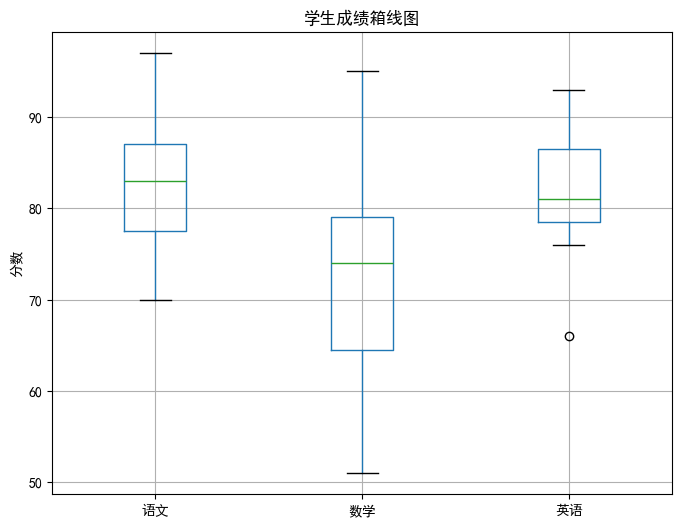

In [18]:
df_grade = pd.read_csv('grade_table.csv', sep='\t', encoding='GB2312')
#输出学生成绩表的箱图
num_cols = df_grade.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise ValueError('没有找到用于绘制箱线图的数值列')
else:
    col = num_cols[1:]  # 假设第一个数值列是成绩列

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体（如果你的系统支持）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

plt.figure(figsize=(8,6))
df_grade[col].boxplot()
plt.title('学生成绩箱线图')
plt.ylabel('分数')
plt.show()


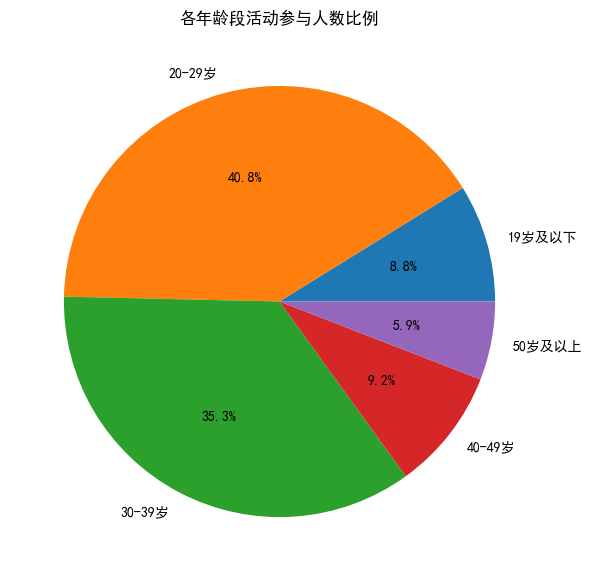

In [ ]:
df_sta = pd.read_csv('activity_statistics.csv', sep='\t', encoding='GB2312')
#输出各年龄段活动参与人数的饼图
if 'age_group' in df_sta.columns:
    group_col = 'age_group'
elif '年龄段' in df_sta.columns:
    group_col = '年龄段'
else:
    # 尝试使用第一个非数值列作为分组
    non_num = df_sta.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(non_num) > 0:
        group_col = non_num[0]
    else:
        raise ValueError('无法识别年龄段的分组列')
if 'count' in df_sta.columns:
    count_col = 'count'
elif '人数' in df_sta.columns:
    count_col = '人数'
else:
    # 聚合为计数并绘图
    agg = df_sta.groupby(group_col).size()
    labels = agg.index.tolist()
    sizes = agg.values.tolist()
    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title('各年龄段活动参与人数比例')
    plt.show()
    # 结束该单元
    
# 如果有显式人数列则绘图
if 'count' in df_sta.columns or '人数' in df_sta.columns:
    labels = df_sta[group_col].astype(str).tolist()
    count_col = 'count' if 'count' in df_sta.columns else '人数'
    sizes = df_sta[count_col].astype(float).tolist()
    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title('各年龄段活动参与人数比例')
    plt.show()


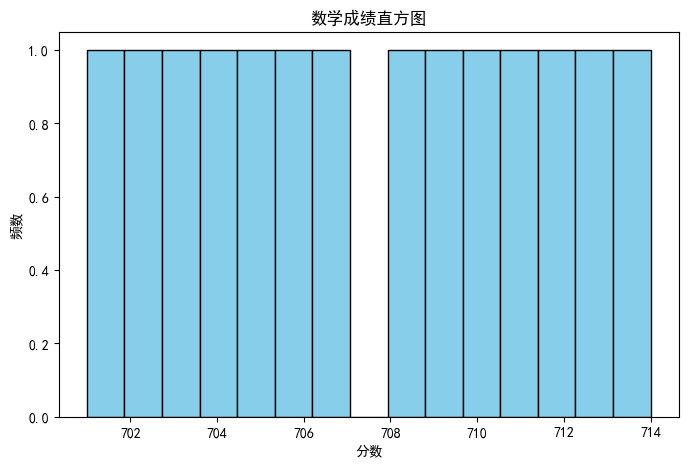

In [20]:
df_math = pd.read_csv('math_grade.csv', sep='\t', encoding='GB2312')
num_cols = df_math.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise ValueError('没有找到用于绘制直方图的数值列')
col = num_cols[0]
plt.figure(figsize=(8,5))
plt.hist(df_math[col].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('数学成绩直方图')
plt.xlabel('分数')
plt.ylabel('频数')
plt.show()


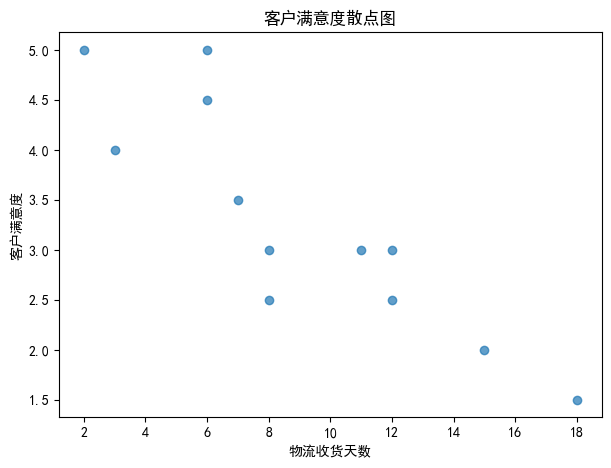

In [21]:
df_satisfied = pd.read_csv('satis_statistics.csv', sep='\t', encoding='GB2312')
# 找到两个数值列用于散点图，优先使用 'satisfaction' 和 'score' 等
num_cols = df_satisfied.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) < 2:
    raise ValueError('需要至少两个数值列来绘制散点图')
xcol, ycol = num_cols[0], num_cols[1]
plt.figure(figsize=(7,5))
plt.scatter(df_satisfied[xcol], df_satisfied[ycol], alpha=0.7)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title('客户满意度散点图')
plt.show()
